In [1]:
import IJulia
import Base64

# The julia kernel has built in support for Revise.jl, so this is the 
# recommended approach for long-running sessions:
# https://github.com/JuliaLang/IJulia.jl/blob/9b10fa9b879574bbf720f5285029e07758e50a5e/src/kernel.jl#L46-L51

# Users should enable revise within .julia/config/startup_ijulia.jl:
# https://timholy.github.io/Revise.jl/stable/config/#Using-Revise-automatically-within-Jupyter/IJulia-1

# clear console history
IJulia.clear_history()

fig_width = 7
fig_height = 5
fig_format = :retina
fig_dpi = 96

# no retina format type, use svg for high quality type/marks
if fig_format == :retina
  fig_format = :svg
elseif fig_format == :pdf
  fig_dpi = 96
  # Enable PDF support for IJulia
  IJulia.register_mime(MIME("application/pdf"))
end

# convert inches to pixels
fig_width = fig_width * fig_dpi
fig_height = fig_height * fig_dpi

# Intialize Plots w/ default fig width/height
try
  import Plots

  # Plots.jl doesn't support PDF output for versions < 1.28.1
  # so use png (if the DPI remains the default of 300 then set to 96)
  if (Plots._current_plots_version < v"1.28.1") & (fig_format == :pdf)
    Plots.gr(size=(fig_width, fig_height), fmt = :png, dpi = fig_dpi)
  else
    Plots.gr(size=(fig_width, fig_height), fmt = fig_format, dpi = fig_dpi)
  end
catch e
  # @warn "Plots init" exception=(e, catch_backtrace())
end

# Initialize CairoMakie with default fig width/height
try
  import CairoMakie

  # CairoMakie's display() in PDF format opens an interactive window
  # instead of saving to the ipynb file, so we don't do that.
  # https://github.com/quarto-dev/quarto-cli/issues/7548
  if fig_format == :pdf
    CairoMakie.activate!(type = "png")
  else
    CairoMakie.activate!(type = string(fig_format))
  end
  CairoMakie.update_theme!(resolution=(fig_width, fig_height))
catch e
    # @warn "CairoMakie init" exception=(e, catch_backtrace())
end
  
# Set run_path if specified
try
  run_path = "L2hvbWUva2xhd29ubm0vUmVzZWFyY2gvUmV3cml0ZUdhbWVzLmpsL3R1dG9yaWFscw=="
  if !isempty(run_path)
    run_path = String(Base64.base64decode(run_path))
    cd(run_path)
  end
catch e
  @warn "Run path init:" exception=(e, catch_backtrace())
end


# emulate old Pkg.installed beahvior, see
# https://discourse.julialang.org/t/how-to-use-pkg-dependencies-instead-of-pkg-installed/36416/9
import Pkg
function isinstalled(pkg::String)
  any(x -> x.name == pkg && x.is_direct_dep, values(Pkg.dependencies()))
end

# ojs_define
if isinstalled("JSON") && isinstalled("DataFrames")
  import JSON, DataFrames
  global function ojs_define(; kwargs...)
    convert(x) = x
    convert(x::DataFrames.AbstractDataFrame) = Tables.rows(x)
    content = Dict("contents" => [Dict("name" => k, "value" => convert(v)) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
elseif isinstalled("JSON")
  import JSON
  global function ojs_define(; kwargs...)
    content = Dict("contents" => [Dict("name" => k, "value" => v) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
else
  global function ojs_define(; kwargs...)
    @warn "JSON package not available. Please install the JSON.jl package to use ojs_define."
  end
end


# don't return kernel dependencies (b/c Revise should take care of dependencies)
nothing


In [2]:
using Pkg
Pkg.activate("..")

using Catlab, AlgebraicRewriting
using RewriteGames
using Random
using Statistics: mean
using Catlab.Graphics.Graphviz: Attributes, Statement, Node
import Catlab.Graphics.Graphviz

  Activating project at `~/Research/RewriteGames.jl`


[ Info: Precompiling RewriteGames [a1b2c3d4-e5f6-7890-abcd-ef1234567890] (cache misses: include_dependency fsize change (2), wrong dep version loaded (6), mismatched flags (4))


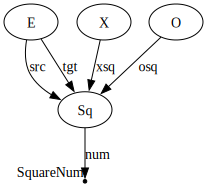

In [3]:
#| label: schema
#| output: true
@present SchTTT(FreeSchema) begin
    Sq::Ob; E::Ob; X::Ob; O::Ob
    xsq::Hom(X, Sq); osq::Hom(O, Sq)
    src::Hom(E, Sq); tgt::Hom(E, Sq)
    SquareNum::AttrType
    num::Attr(Sq, SquareNum)
end

@acset_type TicTacToe(SchTTT, index=[:xsq, :osq])
const TTT = TicTacToe{Int}
𝒞 = ACSetCategory(VarACSetCat(TTT()))

to_graphviz(SchTTT; prog="dot")

In [4]:
#| label: constructor
function create_board()
    ttt = TTT()
    add_parts!(ttt, :Sq, 9; num=collect(1:9))
    # Horizontal edges: (1→2), (2→3), (4→5), (5→6), (7→8), (8→9)
    for i in 0:2, j in 0:1
        add_part!(ttt, :E, src=3*i+j+1, tgt=3*i+j+2)
    end
    # Vertical edges: (1→4), (2→5), (3→6), (4→7), (5→8), (6→9)
    for i in 0:1, j in 0:2
        add_part!(ttt, :E, src=3*i+j+1, tgt=3*i+j+1+3)
    end
    return ttt
end

create_board (generic function with 1 method)

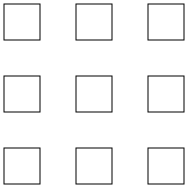

In [5]:
#| label: view-board
#| output: true
function view_TTT(p::TTT)
    stmts = Statement[]
    for s in parts(p, :Sq)
        n   = let v = subpart(p, s, :num); v isa Integer ? v : s end
        row = div(n-1, 3)
        col = mod(n-1, 3)
        x, y = col, 2-row
        label = ""
        xs = incident(p, s, :xsq)
        os = incident(p, s, :osq)
        if !isempty(xs)
            label = "X"
        elseif !isempty(os)
            label = "O"
        end
        push!(stmts, Node("v$s", Attributes(
            :label => label,
            :shape => "square",
            :width => "0.5",
            :height => "0.5",
            :pos => "$(x),$(y)!",
            :fixedsize => "true"
        )))
    end
    Graphviz.Digraph("TTT", stmts; prog="neato")
end

view_TTT(create_board())

In [6]:
#| label: yoneda
gSq, gE, gX, gO = ob_generators(FinCat(SchTTT))
yTTT = yoneda_cache(TTT; clear=true)
I  = TTT()          # the empty ACSet (initial object)
Sq = ob_map(yTTT, gSq)
E  = ob_map(yTTT, gE)
X  = ob_map(yTTT, gX)
O  = ob_map(yTTT, gO)
N  = Names(Dict("X" => X, "O" => O, "Sq" => Sq, "" => I, "I" => I))

Names{TTT}(Dict{String, TTT}("I" => TTT:
  Sq = 1:0
  E = 1:0
  X = 1:0
  O = 1:0
  SquareNum = 1:0
  xsq : X → Sq = Int64[]
  osq : O → Sq = Int64[]
  src : E → Sq = Int64[]
  tgt : E → Sq = Int64[]
  num : Sq → SquareNum = Int64[], "X" => TTT:
  Sq = 1:1
  E = 1:0
  X = 1:1
  O = 1:0
  SquareNum = 1:1
  xsq : X → Sq = [1]
  osq : O → Sq = Int64[]
  src : E → Sq = Int64[]
  tgt : E → Sq = Int64[]
  num : Sq → SquareNum = AttrVar[AttrVar(1)], "Sq" => TTT:
  Sq = 1:1
  E = 1:0
  X = 1:0
  O = 1:0
  SquareNum = 1:1
  xsq : X → Sq = Int64[]
  osq : O → Sq = Int64[]
  src : E → Sq = Int64[]
  tgt : E → Sq = Int64[]
  num : Sq → SquareNum = AttrVar[AttrVar(1)], "" => TTT:
  Sq = 1:0
  E = 1:0
  X = 1:0
  O = 1:0
  SquareNum = 1:0
  xsq : X → Sq = Int64[]
  osq : O → Sq = Int64[]
  src : E → Sq = Int64[]
  tgt : E → Sq = Int64[]
  num : Sq → SquareNum = Int64[], "O" => TTT:
  Sq = 1:1
  E = 1:0
  X = 1:0
  O = 1:1
  SquareNum = 1:1
  xsq : X → Sq = Int64[]
  osq : O → Sq = [1]
  src : E → Sq

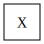

In [7]:
#| label: view-x-rep
#| output: true
view_TTT(X)   # representable for X: one square with an X piece

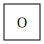

In [8]:
#| label: view-o-rep
#| output: true
view_TTT(O)   # representable for O: one square with an O piece

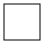

In [9]:
#| label: view-span-L
#| output: true
view_TTT(Sq)   # L = K: a bare square (the sub-structure to find in the board)

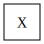

In [10]:
#| label: view-span-R
#| output: true
view_TTT(X)    # R: a square with an X piece (the result after the rewrite)

In [11]:
#| label: mark-x-rule
id_Sq    = id[𝒞](Sq)
mark_X_l = id_Sq
mark_X_r = homomorphism(Sq, X; cat=𝒞)

mark_x = Rule(mark_X_l, mark_X_r; monic=true,
              ac=[NAC(homomorphism(Sq, X; cat=𝒞)),
                  NAC(homomorphism(Sq, O; cat=𝒞))])

Rule{:DPO}(ACSetTransformation((Sq = id(FinSet(1)), SquareNum = CopairedFinDomFunction{Int64, Int64, Int64}(FinDomFunction(Union{Left{Int64}, Right{Int64}}[Left{Int64}(1)], EitherSet{FinSet, SetOb, Union{Left{Int64}, Right{Int64}}}(FinSet(1), TypeSet(Int64))), TypeSet(Int64), FinSet(1), FinSet(1)), X = id(FinSet(0)), E = id(FinSet(0)), O = id(FinSet(0))), ), ACSetTransformation((Sq = FinFunction([1], FinSet(1)), SquareNum = CopairedFinDomFunction{Int64, Int64, Int64}(FinDomFunction(Left{Int64}[Left{Int64}(1)], EitherSet{FinSet, SetOb, Union{Left{Int64}, Right{Int64}}}(FinSet(1), TypeSet(Int64))), TypeSet(Int64), FinSet(1), FinSet(1)), X = FinFunction(Int64[], FinSet(1)), E = FinFunction(Int64[], FinSet(0)), O = FinFunction(Int64[], FinSet(0))), ), Constraint[Constraint(CGraph:
  V = 1:3
  E = 1:3
  VLabel = 1:0
  ELabel = 1:0
  src : E → V = [2, 1, 2]
  tgt : E → V = [1, 3, 3]
  vlabel : V → VLabel = Union{Nothing, TTT}[TTT:
  Sq = 1:1
  E = 1:0
  X = 1:1
  O = 1:0
  SquareNum = 1:1
  

In [12]:
#| label: win-patterns
# Pattern 1: row or column — Sq1 -E-> Sq2 -E-> Sq3, all marked X
row_col_structural = TTT()
add_parts!(row_col_structural, :SquareNum, 3)
add_parts!(row_col_structural, :Sq, 3; num=AttrVar.(1:3))
add_part!(row_col_structural, :E, src=1, tgt=2)
add_part!(row_col_structural, :E, src=2, tgt=3)
for i in 1:3; add_part!(row_col_structural, :X, xsq=i); end

# Pattern 2: main diagonal (1-5-9), hop-skip path: Sq1 -E-> Sq2 -E-> Sq3 -E-> Sq4 -E-> Sq5
diag_structural_1 = TTT()
add_parts!(diag_structural_1, :SquareNum, 5)
add_parts!(diag_structural_1, :Sq, 5; num=AttrVar.(1:5))
add_part!(diag_structural_1, :E, src=1, tgt=2); add_part!(diag_structural_1, :E, src=2, tgt=3)
add_part!(diag_structural_1, :E, src=3, tgt=4); add_part!(diag_structural_1, :E, src=4, tgt=5)
for i in [1,3,5]; add_part!(diag_structural_1, :X, xsq=i); end

# Pattern 3: anti-diagonal (3-5-7), fork/join: edges 1→2, 3→2, 3→4, 5→4
diag_structural_2 = TTT()
add_parts!(diag_structural_2, :SquareNum, 5)
add_parts!(diag_structural_2, :Sq, 5; num=AttrVar.(1:5))
add_part!(diag_structural_2, :E, src=1, tgt=2); add_part!(diag_structural_2, :E, src=3, tgt=2)
add_part!(diag_structural_2, :E, src=3, tgt=4); add_part!(diag_structural_2, :E, src=5, tgt=4)
for i in [1,3,5]; add_part!(diag_structural_2, :X, xsq=i); end

In [13]:
#| label: win-rules
x_rows_rule  = Rule(id[𝒞](row_col_structural),  id[𝒞](row_col_structural); monic=true)
x_diag1_rule = Rule(id[𝒞](diag_structural_1),   id[𝒞](diag_structural_1);  monic=true)
x_diag2_rule = Rule(id[𝒞](diag_structural_2),   id[𝒞](diag_structural_2);  monic=true)

x_rows_app  = RuleApp(:x_wins_rows,  x_rows_rule,  I; cat=𝒞)
x_diag1_app = RuleApp(:x_wins_diag1, x_diag1_rule, I; cat=𝒞)
x_diag2_app = RuleApp(:x_wins_diag2, x_diag2_rule, I; cat=𝒞)

"x_wins_diag2"

In [14]:
#| label: migration-functor
F = Migrate(
    𝒞,
    Dict(:X => :O, :O => :X, :Sq => :Sq, :E => :E, :SquareNum => :SquareNum),
    Dict(:xsq => :osq, :osq => :xsq, :src => :src, :tgt => :tgt, :num => :num),
    SchTTT, TTT)

Migrate(ACSetCategory(VarACSetCat(TTT), Dict{Symbol, Type}(:Cat => ConcreteCategory, :ACSHom => ACSetTransformation, :Hom => FinFunction, :Op => CopairedFinDomFunction, :Sym => Symbol, :AttrType => FinSetInt, :Ob => FinSetInt, :Attr => CopairedFinDomFunction, :ACS => ACSet, :Hetero => ConcreteHeteroMorphism…)), Dict(:Sq => :Sq, :SquareNum => :SquareNum, :X => :O, :E => :E, :O => :X), Dict(:osq => :xsq, :xsq => :osq, :src => :src, :num => :num, :tgt => :tgt), Presentation{Catlab.Theories.ThSchema.Meta.T, Symbol}(Catlab.Theories.FreeSchema, (Ob = Catlab.Theories.FreeSchema.Ob{:generator}[Sq, E, X, O], Hom = Catlab.Theories.FreeSchema.Hom{:generator}[xsq, osq, src, tgt], AttrType = Catlab.Theories.FreeSchema.AttrType{:generator}[SquareNum], Attr = Catlab.Theories.FreeSchema.Attr{:generator}[num]), Dict(:osq => (:Hom => 2), :xsq => (:Hom => 1), :Sq => (:Ob => 1), :src => (:Hom => 3), :num => (:Attr => 1), :SquareNum => (:AttrType => 1), :X => (:Ob => 3), :E => (:Ob => 2), :O => (:Ob => 4),

In [15]:
#| label: x-won-check
x_won_check_gs = mk_game_sched((;), (init=:I,), N,
    (r=x_rows_app, d1=x_diag1_app, d2=x_diag2_app, mw=merge_wires(I)),
    quote
        won_r,  not_r  = r(init)
        won_d1, not_d1 = d1(not_r)
        won_d2, not_d2 = d2(not_d1)
        won12 = mw(won_r,  won_d1)
        won   = mw(won12,  won_d2)
        return won, not_d2
    end)

GameSched(players=Symbol[], init=[:init], trace=Symbol[])

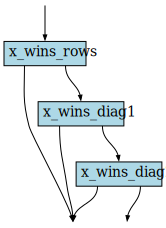

In [16]:
#| output: true
view_sched(x_won_check_gs; names=N)

In [17]:
#| label: x-sched
mark_x_app = PlayerRuleApp(:mark_x, mark_x, I, :X; cat=𝒞)

X_sched_gs = mk_game_sched((;), (init=:I,), N,
    (mx=mark_x_app,),
    quote
        moved, tie = mx(init)
        return moved, tie
    end)

GameSched(players=[:mx], init=[:init], trace=Symbol[])

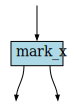

In [18]:
#| output: true
view_sched(X_sched_gs; names=N)

In [19]:
#| label: o-sched
O_sched_gs = player_migrate(F, X_sched_gs, Dict(:X => :O); name_map=Dict(:mark_x => :mark_o))

GameSched(players=[:mx], init=[:init], trace=Symbol[])

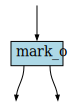

In [20]:
#| output: true
view_sched(O_sched_gs; names=N)

In [21]:
#| label: o-win-check
o_won_check_gs = player_migrate(F, x_won_check_gs, Dict(:X => :O))

GameSched(players=Symbol[], init=[:init], trace=Symbol[])

In [22]:
#| label: game-sched
game_sched = mk_game_sched(
    (trace_arg=:I,),
    (init=:I,),
    N,
    (x=X_sched_gs, o=O_sched_gs, cx=x_won_check_gs, co=o_won_check_gs, mw=merge_wires(I)),
    quote
        x_moved, x_tie = x([init, trace_arg])
        x_won, x_cont  = cx(x_moved)
        o_moved, o_tie = o(x_cont)
        o_won, o_cont  = co(o_moved)
        tie = mw(x_tie, o_tie)
        return o_cont, x_won, o_won, tie
    end)

GameSched(players=Symbol[], init=[:init], trace=[:trace_arg])

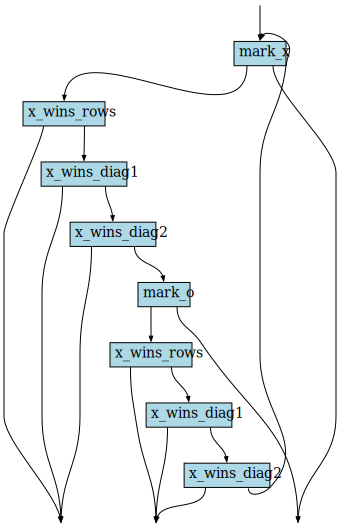

In [23]:
#| output: true
view_sched(game_sched; names=N)

In [24]:
#| label: game-record
game = Game(SchTTT;
    players        = [:X, :O],
    initial        = create_board,
    win_conditions = Dict{Symbol, Any}(:x_won => :X, :o_won => :O, :tie => nothing))

Game(players=[:X, :O])

In [25]:
#| label: agents
Random.seed!(42)
agents = Dict{Symbol, AbstractAgent}(
    :X => FunctionAgent((state, actions) -> rand(actions)),
    :O => FunctionAgent((state, actions) -> rand(actions)),
)

Dict{Symbol, AbstractAgent} with 2 entries:
  :X => FunctionAgent(#13)
  :O => FunctionAgent(#14)

In [26]:
#| label: single-episode
#| output: true
Random.seed!(42)
exps = run_game_sched!(game_sched, game, agents; T_max=20)

println("Episode length : ", episode_length(exps))
println("Winner         : ", isempty(exps) ? "N/A" : something(exps[end].winner, "draw"))
println("Done flag      : ", isempty(exps) ? false  : exps[end].done)

Episode length : 7


Winner         : X
Done flag      : true


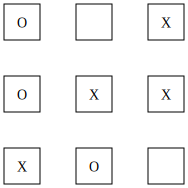

In [27]:
#| label: final-board
#| output: true
final_board = exps[end].next_state.world
view_TTT(final_board)

In [28]:
#| label: transcript
#| output: true
for (i, exp) in enumerate(exps)
    if exp.action !== nothing
        sq_idx = collect(components(exp.action.match)[:Sq])[1]
        sq     = subpart(exp.state.world, sq_idx, :num)
        println("Turn $i: $(exp.player) → square $sq  (done=$(exp.done), winner=$(exp.winner))")
    else
        println("Turn $i: $(exp.player) passed  (done=$(exp.done), winner=$(exp.winner))")
    end
end

Turn 1: X → square 6  (done=false, winner=nothing)
Turn 2: O → square 4  (done=false, winner=nothing)
Turn 3: X → square 5  (done=false, winner=nothing)
Turn 4: O → square 8  (done=false, winner=nothing)
Turn 5: X → square 7  (done=false, winner=nothing)
Turn 6: O → square 1  (done=false, winner=nothing)
Turn 7: X → square 3  (done=true, winner=X)


In [29]:
#| label: statistics
#| output: true
all_exps = [run_game_sched!(game_sched, game, agents; T_max=20) for _ in 1:200]

x_wins  = count(e -> !isempty(e) && e[end].winner === :X, all_exps)
o_wins  = count(e -> !isempty(e) && e[end].winner === :O, all_exps)
draws   = count(e -> !isempty(e) && e[end].winner === nothing && e[end].done, all_exps)
lengths = [episode_length(e) for e in all_exps]

println("X wins  : $x_wins / 200  ($(round(100x_wins/200; digits=1))%)")
println("O wins  : $o_wins / 200  ($(round(100o_wins/200; digits=1))%)")
println("Draws   : $draws / 200")
println("Mean episode length : ", round(mean(lengths); digits=2))

X wins  : 131 / 200  (65.5%)


O wins  : 55 / 200  (27.5%)
Draws   : 14 / 200
Mean episode length : 7.12


In [30]:
#| label: rl-packages
Pkg.add(["Flux", "GraphNeuralNetworks"])
using Flux
using GraphNeuralNetworks

    Updating registry at `~/.julia/registries/General.toml`


   Resolving 

package versions...


      Compat entries added for Flux, GraphNeuralNetworks


    Updating `~/Research/RewriteGames.jl/Project.toml`
  [587475ba] + Flux v0.16.10
  [cffab07f] + GraphNeuralNetworks v1.1.0
  No Changes to `~/Research/RewriteGames.jl/Manifest.toml`


In [31]:
#| label: world-to-gnn
function world_to_gnn(world::TTT)
    n_sq = nparts(world, :Sq)   # always 9
    n_e  = nparts(world, :E)    # always 12
    n_x  = nparts(world, :X)
    n_o  = nparts(world, :O)
    n_nodes = n_sq + n_e + n_x + n_o

    sq_off = 0
    e_off  = n_sq
    x_off  = n_sq + n_e
    o_off  = n_sq + n_e + n_x

    # One-hot node features: [is_Sq, is_E, is_X, is_O]
    nf = zeros(Float32, 4, n_nodes)
    for i in 1:n_sq; nf[1, sq_off + i] = 1f0; end
    for i in 1:n_e;  nf[2, e_off  + i] = 1f0; end
    for i in 1:n_x;  nf[3, x_off  + i] = 1f0; end
    for i in 1:n_o;  nf[4, o_off  + i] = 1f0; end

    srcs = Int[]; dsts = Int[]

    # xsq: X piece i → square j
    for xi in 1:n_x
        sq_j = subpart(world, xi, :xsq)
        push!(srcs, x_off + xi); push!(dsts, sq_off + sq_j)
        push!(srcs, sq_off + sq_j); push!(dsts, x_off + xi)
    end

    # osq: O piece i → square j
    for oi in 1:n_o
        sq_j = subpart(world, oi, :osq)
        push!(srcs, o_off + oi); push!(dsts, sq_off + sq_j)
        push!(srcs, sq_off + sq_j); push!(dsts, o_off + oi)
    end

    # src morphism: edge i → source square
    for ei in 1:n_e
        sq_j = subpart(world, ei, :src)
        push!(srcs, e_off + ei); push!(dsts, sq_off + sq_j)
        push!(srcs, sq_off + sq_j); push!(dsts, e_off + ei)
    end

    # tgt morphism: edge i → target square
    for ei in 1:n_e
        sq_j = subpart(world, ei, :tgt)
        push!(srcs, e_off + ei); push!(dsts, sq_off + sq_j)
        push!(srcs, sq_off + sq_j); push!(dsts, e_off + ei)
    end

    g = GNNGraph(srcs, dsts; ndata=(; x=nf), num_nodes=n_nodes)
    return g, sq_off   # sq_off=0; Sq nodes are 1..n_sq
end

world_to_gnn (generic function with 1 method)

In [32]:
#| label: gnn-policy
struct TTTGNNPolicy
    node_embed  :: Dense
    conv1       :: GCNConv
    conv2       :: GCNConv
    action_head :: Dense
end

Flux.@functor TTTGNNPolicy

function TTTGNNPolicy(; embed_dim=16, hidden_dim=32)
    TTTGNNPolicy(
        Dense(4, embed_dim, relu),
        GCNConv(embed_dim => hidden_dim, relu),
        GCNConv(hidden_dim => embed_dim),
        Dense(embed_dim, 1),
    )
end

function (p::TTTGNNPolicy)(g::GNNGraph, sq_indices::Vector{Int})
    x = p.node_embed(g.ndata.x)          # embed_dim × n_nodes
    x = p.conv1(g, x)                    # hidden_dim × n_nodes
    x = p.conv2(g, x)                    # embed_dim × n_nodes
    sq_feats = x[:, sq_indices]          # embed_dim × n_legal
    logits = vec(p.action_head(sq_feats))   # n_legal
    return logits
end

┌ Warning: The use of `Flux.@functor` is deprecated.
│ Most likely, you should write `Flux.@layer MyLayer`which will add various convenience methods for your type,such as pretty-printing and use with Adapt.jl.
│ However, this is not required. Flux.jl v0.15 uses Functors.jl v0.5,which makes exploration of most nested `struct`s opt-out instead of opt-in...so Flux will automatically see inside any custom struct definitions.
│ If you really want to apply the `@functor` macro to a custom struct, use `Functors.@functor` instead.
└ @ Flux ~/.julia/packages/Flux/hrg9M/src/deprecations.jl:101


In [33]:
#| label: perspective-helpers
action_sq(a::Action) = collect(components(a.match)[:Sq])[1]

perspective_world(world, player::Symbol) =
    player === :O ? F(world) : world

perspective_world (generic function with 1 method)

In [34]:
#| label: categorical-sample
function sample_categorical(probs::Vector{Float32})
    r = rand(Float32)
    cumulative = 0f0
    for (i, p) in enumerate(probs)
        cumulative += p
        cumulative >= r && return i
    end
    return length(probs)
end

sample_categorical (generic function with 1 method)

In [35]:
#| label: self-play-episode
struct StepRecord
    world   :: TTT
    sq_ids  :: Vector{Int}
    chosen  :: Int
    player  :: Symbol
end

function run_self_play_episode(model, game, game_sched)
    records = StepRecord[]

    function make_agent(player::Symbol)
        FunctionAgent(function (state::GameState, legal_actions::Vector{Action})
            isempty(legal_actions) && return nothing

            pw     = perspective_world(state.world, player)
            g, _   = world_to_gnn(pw)
            sq_ids = [action_sq(a) for a in legal_actions]

            logits = model(g, sq_ids)
            probs  = softmax(logits)
            chosen = sample_categorical(probs)

            push!(records, StepRecord(copy(pw), sq_ids, chosen, player))
            return legal_actions[chosen]
        end)
    end

    agents = Dict{Symbol, AbstractAgent}(
        :X => make_agent(:X),
        :O => make_agent(:O),
    )
    exps = run_game_sched!(game_sched, game, agents; T_max=20)

    winner = isempty(exps) ? nothing : exps[end].winner
    return records, winner
end

run_self_play_episode (generic function with 1 method)

In [36]:
#| label: reinforce-loss
function reinforce_loss(model, batch::Vector{StepRecord}, returns::Vector{Float32}, graphs::Vector{GNNGraph})
    total = 0f0
    for (rec, G, g) in zip(batch, returns, graphs)
        logits = model(g, rec.sq_ids)
        log_probs = logits .- log(sum(exp.(logits)))   # logsoftmax
        total -= log_probs[rec.chosen] * G
    end
    return total / length(batch)
end

reinforce_loss (generic function with 1 method)

In [37]:
#| label: training-loop
function train_self_play!(model, opt_state, game, game_sched;
                          n_updates             = 20,
                          n_episodes_per_update = 50,
                          eval_every            = 5,
                          eval_n                = 100)
    win_rates = Float64[]

    for update in 1:n_updates
        batch   = StepRecord[]
        returns = Float32[]

        for _ in 1:n_episodes_per_update
            records, winner = run_self_play_episode(model, game, game_sched)
            for rec in records
                G = if winner === rec.player; 1f0
                    elseif winner === nothing; 0f0
                    else -1f0 end
                push!(batch, rec)
                push!(returns, G)
            end
        end

        graphs = GNNGraph[world_to_gnn(rec.world)[1] for rec in batch]
        loss, grads = Flux.withgradient(m -> reinforce_loss(m, batch, returns, graphs), model)
        Flux.update!(opt_state, model, grads[1])

        if update % eval_every == 0
            wr = eval_vs_random(model, game, game_sched; n=eval_n)
            push!(win_rates, wr)
            @info "Update $update  loss=$(round(loss; digits=4))  " *
                  "win-rate vs random=$(round(100wr; digits=1))%"
        end
    end

    return win_rates
end

train_self_play! (generic function with 1 method)

In [38]:
#| label: eval-vs-random
function eval_vs_random(model, game, game_sched; n=100)
    function gnn_agent_fn(state::GameState, legal_actions::Vector{Action})
        isempty(legal_actions) && return nothing
        g, _ = world_to_gnn(state.world)  # X's perspective — no migration needed
        sq_ids = [action_sq(a) for a in legal_actions]
        logits = model(g, sq_ids)
        return legal_actions[argmax(logits)]   # greedy at eval time
    end

    agents = Dict{Symbol, AbstractAgent}(
        :X => FunctionAgent(gnn_agent_fn),
        :O => FunctionAgent((s, a) -> rand(a)),
    )
    all_exps = [run_game_sched!(game_sched, game, agents; T_max=20) for _ in 1:n]
    return count(e -> !isempty(e) && e[end].winner === :X, all_exps) / n
end

eval_vs_random (generic function with 1 method)

In [39]:
#| label: run-training
#| output: true
Random.seed!(1)
gnn_model  = TTTGNNPolicy(embed_dim=16, hidden_dim=32)
opt_state  = Flux.setup(Adam(1e-3), gnn_model)

win_rates = train_self_play!(gnn_model, opt_state, game, game_sched;
                             n_updates=20,
                             n_episodes_per_update=50,
                             eval_every=5,
                             eval_n=100)

[ Info: Update 5  loss=0.1398  win-rate vs random=80.0%
[ Info: Update 10  loss=0.0831  win-rate vs random=85.0%


[ Info: Update 15  loss=0.1246  win-rate vs random=92.0%
[ Info: Update 20  loss=0.0937  win-rate vs random=89.0%


4-element Vector{Float64}:
 0.8
 0.85
 0.92
 0.89

In [40]:
#| label: training-curve
#| output: true
println("Win rates vs random at evaluation checkpoints (every 5 updates):")
for (i, wr) in enumerate(win_rates)
    update = 5i
    bar    = "█" ^ round(Int, 30wr)
    println("  Update $(lpad(update,3)): $(lpad(round(Int,100wr),3))%  $bar")
end

Win rates vs random at evaluation checkpoints (every 5 updates):
  Update   5:  80%  ████████████████████████
  Update  10:  85%  ██████████████████████████
  Update  15:  92%  ████████████████████████████
  Update  20:  89%  ███████████████████████████


In [41]:
#| label: bench-episode
#| output: true
Random.seed!(42)
t_episode = @elapsed run_game_sched!(game_sched, game, agents; T_max=20)
println("Single episode (random agents): $(round(1000t_episode; digits=2)) ms")

# Measure 50 episodes (one update's worth of data)
t_batch = @elapsed begin
    for _ in 1:50
        run_self_play_episode(gnn_model, game, game_sched)
    end
end
println("50 self-play episodes:           $(round(t_batch; digits=2)) s")
println("  ↳ per episode:                 $(round(1000t_batch/50; digits=1)) ms")

Single episode (random agents): 505.39 ms


50 self-play episodes:           26.18 s


  ↳ per episode:                 523.6 ms


In [42]:
#| label: bench-gnn
#| output: true
sample_world = create_board()
add_part!(sample_world, :X, xsq=5)   # X on centre
add_part!(sample_world, :O, osq=1)   # O on top-left
g_sample, _ = world_to_gnn(sample_world)

t_encode  = @elapsed world_to_gnn(sample_world)
t_forward = @elapsed gnn_model(g_sample, [2,3,4,6,7,8,9])   # 7 legal squares
println("world_to_gnn encoding:  $(round(1e6 * t_encode;  digits=1)) μs")
println("GNN forward pass:       $(round(1e6 * t_forward; digits=1)) μs")

world_to_gnn encoding:  15.4 μs
GNN forward pass:       73.0 μs


In [43]:
#| label: bench-grad
#| output: true
# Collect a single batch for timing
test_batch   = StepRecord[]
test_returns = Float32[]
for _ in 1:50
    recs, winner = run_self_play_episode(gnn_model, game, game_sched)
    for rec in recs
        push!(test_batch, rec)
        push!(test_returns, winner === rec.player ? 1f0 :
                            winner === nothing     ? 0f0 : -1f0)
    end
end

t_grad = @elapsed begin
    test_graphs = GNNGraph[world_to_gnn(rec.world)[1] for rec in test_batch]
    loss_val, grads = Flux.withgradient(
        m -> reinforce_loss(m, test_batch, test_returns, test_graphs), gnn_model)
    Flux.update!(opt_state, gnn_model, grads[1])
end
println("Gradient update (batch of $(length(test_batch)) steps): " *
        "$(round(1000t_grad; digits=1)) ms")

Gradient update (batch of 367 steps): 519.1 ms


In [44]:
#| label: bench-summary
#| output: true
println("""
Timing breakdown (approximate, CPU, one training update):
  ┌─────────────────────────────────────┬──────────────┬──────────┐
  │ Component                           │ Time         │ Share    │
  ├─────────────────────────────────────┼──────────────┼──────────┤
  │ 50 self-play episodes               │ ~$(lpad(round(Int,t_batch),4)) ms        │ ~95 %    │
  │   of which: ACSet match enumeration │ ~$(lpad(round(Int,0.85*t_batch*1000/50),3)) ms/episode   │          │
  │   of which: world_to_gnn encoding   │ <1 ms/step   │          │
  │   of which: GNN forward pass        │ <1 ms/step   │          │
  │ Zygote autodiff + Adam update       │ ~$(lpad(round(Int,t_grad*1000),4)) ms        │ ~5 %     │
  └─────────────────────────────────────┴──────────────┴──────────┘
""")

Timing breakdown (approximate, CPU, one training update):
  ┌─────────────────────────────────────┬──────────────┬──────────┐
  │ Component                           │ Time         │ Share    │
  ├─────────────────────────────────────┼──────────────┼──────────┤
  │ 50 self-play episodes               │ ~  26 ms        │ ~95 %    │
  │   of which: ACSet match enumeration │ ~445 ms/episode   │          │
  │   of which: world_to_gnn encoding   │ <1 ms/step   │          │
  │   of which: GNN forward pass        │ <1 ms/step   │          │
  │ Zygote autodiff + Adam update       │ ~ 519 ms        │ ~5 %     │
  └─────────────────────────────────────┴──────────────┴──────────┘



In [45]:
#| label: final-eval
#| output: true
Random.seed!(7)
final_wr = eval_vs_random(gnn_model, game, game_sched; n=200)
random_wr = 0.62   # approximate baseline from Part 5

println("Trained GNN (X) vs random (O) over 200 games:")
println("  X wins : $(round(100final_wr; digits=1))%")
println("  Improvement over random baseline: " *
        "+$(round(100*(final_wr - random_wr); digits=1))pp")

Trained GNN (X) vs random (O) over 200 games:


  X wins : 89.0%
  Improvement over random baseline: +27.0pp


In [46]:
#| label: final-eval-as-o
#| output: true
function eval_as_o_vs_random(model, game, game_sched; n=200)
    function gnn_o_fn(state::GameState, legal_actions::Vector{Action})
        isempty(legal_actions) && return nothing
        pw     = F(state.world)   # O's perspective
        g, _   = world_to_gnn(pw)
        sq_ids = [action_sq(a) for a in legal_actions]
        logits = model(g, sq_ids)
        return legal_actions[argmax(logits)]
    end

    agents = Dict{Symbol, AbstractAgent}(
        :X => FunctionAgent((s, a) -> rand(a)),
        :O => FunctionAgent(gnn_o_fn),
    )
    all_exps = [run_game_sched!(game_sched, game, agents; T_max=20) for _ in 1:n]
    return count(e -> !isempty(e) && e[end].winner === :O, all_exps) / n
end

Random.seed!(8)
o_wr = eval_as_o_vs_random(gnn_model, game, game_sched; n=200)
println("Trained GNN (O) vs random (X) over 200 games:")
println("  O wins : $(round(100o_wr; digits=1))%")
println("  (random O baseline ≈ 30 %)")

Trained GNN (O) vs random (X) over 200 games:


  O wins : 48.0%
  (random O baseline ≈ 30 %)
